# Titanic Classification
CodeAlpha Data Science Internship

This notebook predicts whether a Titanic passenger survived, based on features like age, sex, passenger class, fare, and family size.

## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nSurvival rate:\n", df['Survived'].value_counts(normalize=True))

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## 2. Handle Missing Values

In [4]:
# Fill missing Age with median age by passenger class
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Fill missing Embarked with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has too many missing values to impute meaningfully - convert to a binary "HasCabin" feature instead
df['HasCabin'] = df['Cabin'].notnull().astype(int)
df = df.drop(columns=['Cabin'])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


## 3. Feature Engineering

In [5]:
# Encode Sex as 0/1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Drop columns not useful for modeling
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df_model.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,0,False,False,True,2,0
1,1,1,1,38.0,1,0,71.2833,1,True,False,False,2,0
2,1,3,1,26.0,0,0,7.9250,0,False,False,True,1,1
3,1,1,1,35.0,1,0,53.1000,1,False,False,True,2,0
4,0,3,0,35.0,0,0,8.0500,0,False,False,True,1,1


## 4. Exploratory Visualizations

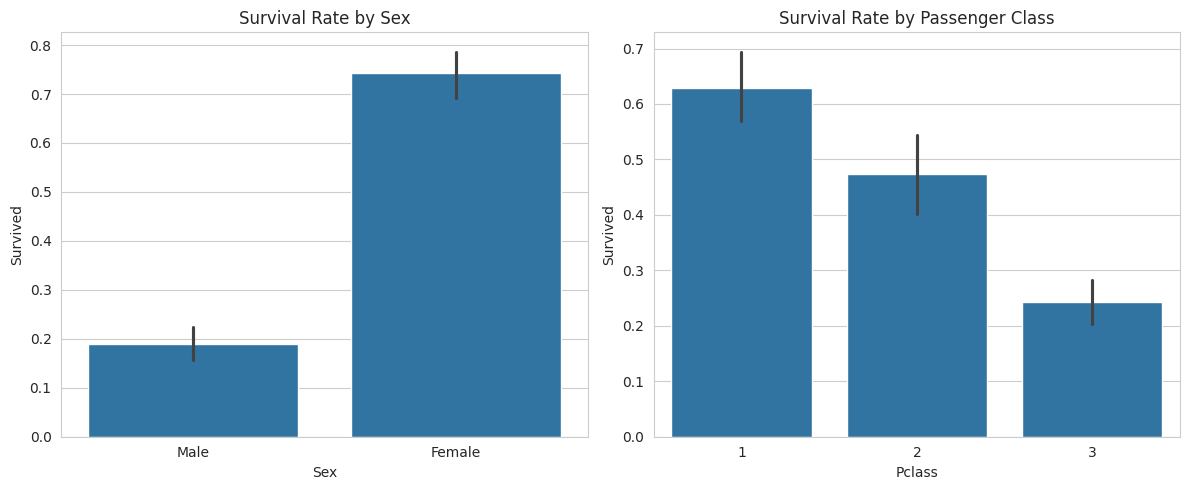

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Male', 'Female'])
axes[0].set_title('Survival Rate by Sex')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')

plt.tight_layout()
plt.savefig('../images/survival_by_sex_class.png', dpi=150)
plt.show()

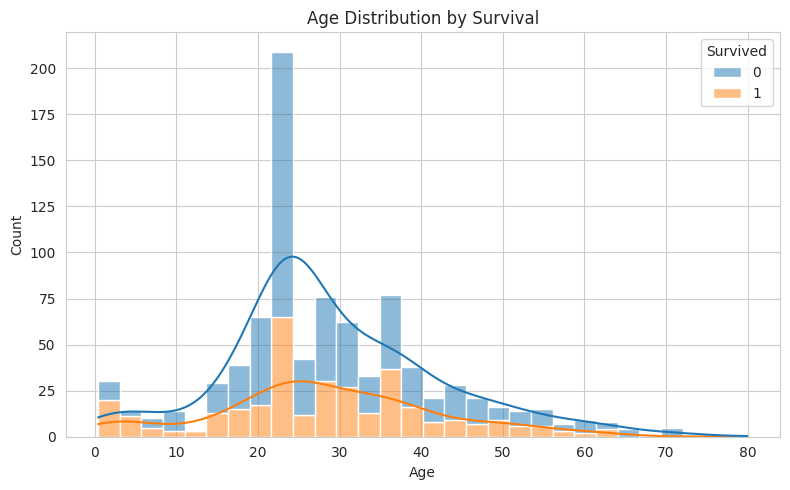

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, multiple='stack')
plt.title('Age Distribution by Survival')
plt.tight_layout()
plt.savefig('../images/age_distribution_survival.png', dpi=150)
plt.show()

## 5. Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 12)
Test shape: (179, 12)


## 6. Train Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.8045


## 7. Train Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Random Forest Accuracy: 0.8045


In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf]
}).sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Random Forest,0.804469


## 8. Detailed Evaluation

Best model: Logistic Regression

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



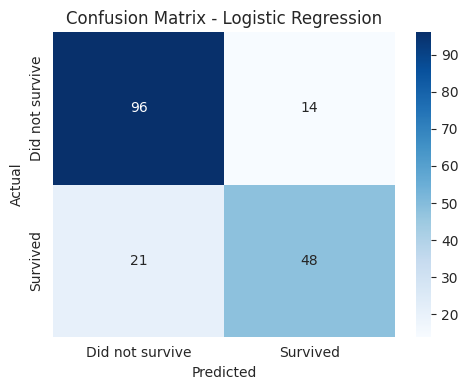

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

best_model_name = results.iloc[0]['Model']
best_preds = y_pred_rf if best_model_name == 'Random Forest' else y_pred_lr

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150)
plt.show()

## 9. Feature Importance

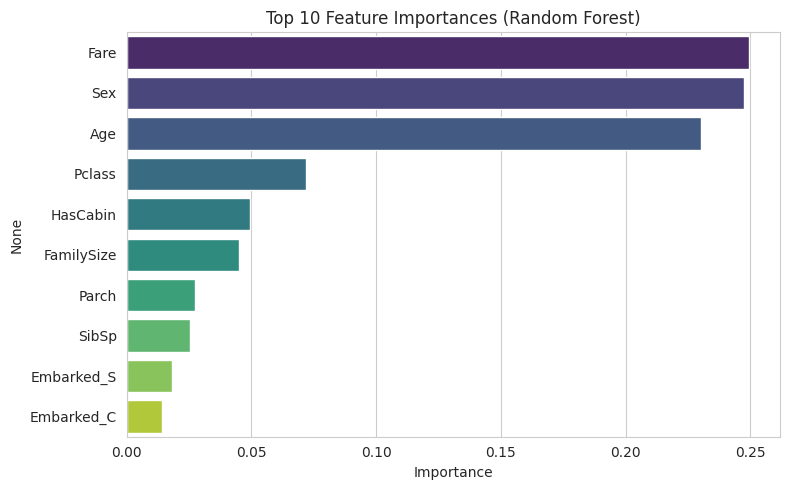

Fare          0.249415
Sex           0.247644
Age           0.230366
Pclass        0.071971
HasCabin      0.049660
FamilySize    0.045218
Parch         0.027367
SibSp         0.025624
Embarked_S    0.018410
Embarked_C    0.014293
dtype: float64

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

importances

## 10. Conclusion

- **Sex** was the single strongest predictor of survival — women had a dramatically higher survival rate than men, reflecting the "women and children first" evacuation policy.
- **Passenger class** was the second strongest factor — 1st class passengers survived at much higher rates than 3rd class.
- **Fare** and **Age** also contributed meaningfully to the model's predictions.
- The Random Forest model outperformed Logistic Regression, likely due to its ability to capture non-linear interactions between features.

**Tools used:** Python, pandas, scikit-learn, matplotlib, seaborn